In [9]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import pywt
import mne

plt.rcParams["figure.figsize"] = (12, 5)
os.makedirs("figures_lab3", exist_ok=True)

In [11]:
FILE_ID = 50

edf_path = f"/kaggle/input/datasets/ahmadhamed1046/dataset/eeg50 (1).edf"
ann_path = "/kaggle/input/datasets/ahmadhamed1046/dataset/annotations_2017_A.csv"

In [12]:
# Читаем аннотации без заголовка: столбцы соответствуют eeg1..eeg79
ann = pd.read_csv(ann_path, header=None)

print("Размер таблицы аннотаций:", ann.shape)

if ann.shape[1] < FILE_ID:
    raise ValueError(f"В таблице аннотаций меньше {FILE_ID} столбцов.")

seizure_vec = pd.to_numeric(ann.iloc[:, FILE_ID - 1], errors="coerce").fillna(0).astype(int)
print("Длина вектора аннотаций (сек):", len(seizure_vec))
print("Уникальные значения:", seizure_vec.unique())

Размер таблицы аннотаций: (15417, 79)
Длина вектора аннотаций (сек): 15417
Уникальные значения: [50  0  1]


In [13]:
def find_seizure_intervals(binary_vector):
    intervals = []
    in_event = False
    start = None

    for i, v in enumerate(binary_vector):
        if v == 1 and not in_event:
            start = i
            in_event = True
        elif v == 0 and in_event:
            intervals.append((start, i - 1))
            in_event = False

    if in_event:
        intervals.append((start, len(binary_vector) - 1))

    return intervals

intervals = find_seizure_intervals(seizure_vec.values)

print("Найденные интервалы приступов:", intervals[:10])
print("Количество интервалов:", len(intervals))

if len(intervals) == 0:
    raise ValueError("В выбранной записи по данной аннотации не найдено приступов.")

seizure_start_sec, seizure_end_sec = intervals[0]
print(f"Первый интервал приступа: {seizure_start_sec} - {seizure_end_sec} сек")

Найденные интервалы приступов: [(454, 542), (1573, 1670), (2269, 2359), (4127, 4223), (4573, 4666), (5423, 5526), (5999, 6095), (6978, 7079), (7350, 7419), (7741, 7828)]
Количество интервалов: 10
Первый интервал приступа: 454 - 542 сек


In [14]:
raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

print(raw)
print("Частота дискретизации:", raw.info["sfreq"])
print("Количество каналов:", len(raw.ch_names))
print("Названия каналов:")
print(raw.ch_names)


<RawEDF | eeg50 (1).edf, 21 x 2521600 (9850.0 s), ~404.0 MiB, data loaded>
Частота дискретизации: 256.0
Количество каналов: 21
Названия каналов:
['EEG Fp1-Ref', 'EEG Fp2-Ref', 'EEG F3-Ref', 'EEG F4-Ref', 'EEG F7-Ref', 'EEG F8-Ref', 'EEG Fz-Ref', 'EEG C3-Ref', 'EEG C4-Ref', 'EEG Cz-Ref', 'EEG T3-Ref', 'EEG T5-Ref', 'EEG T4-Ref', 'EEG T6-Ref', 'EEG P3-Ref', 'EEG P4-Ref', 'EEG Pz-Ref', 'EEG O1-Ref', 'EEG O2-Ref', 'ECG EKG', 'Resp Effort']


In [15]:
# Стараемся оставить только EEG-каналы. Если типы каналов не размечены,
# используем все каналы записи.
try:
    raw_eeg = raw.copy().pick("eeg")
    if len(raw_eeg.ch_names) == 0:
        raw_eeg = raw.copy()
except Exception:
    raw_eeg = raw.copy()

print("Каналы для анализа:", raw_eeg.ch_names)
print("Количество используемых каналов:", len(raw_eeg.ch_names))

Каналы для анализа: ['EEG Fp1-Ref', 'EEG Fp2-Ref', 'EEG F3-Ref', 'EEG F4-Ref', 'EEG F7-Ref', 'EEG F8-Ref', 'EEG Fz-Ref', 'EEG C3-Ref', 'EEG C4-Ref', 'EEG Cz-Ref', 'EEG T3-Ref', 'EEG T5-Ref', 'EEG T4-Ref', 'EEG T6-Ref', 'EEG P3-Ref', 'EEG P4-Ref', 'EEG Pz-Ref', 'EEG O1-Ref', 'EEG O2-Ref', 'ECG EKG', 'Resp Effort']
Количество используемых каналов: 21


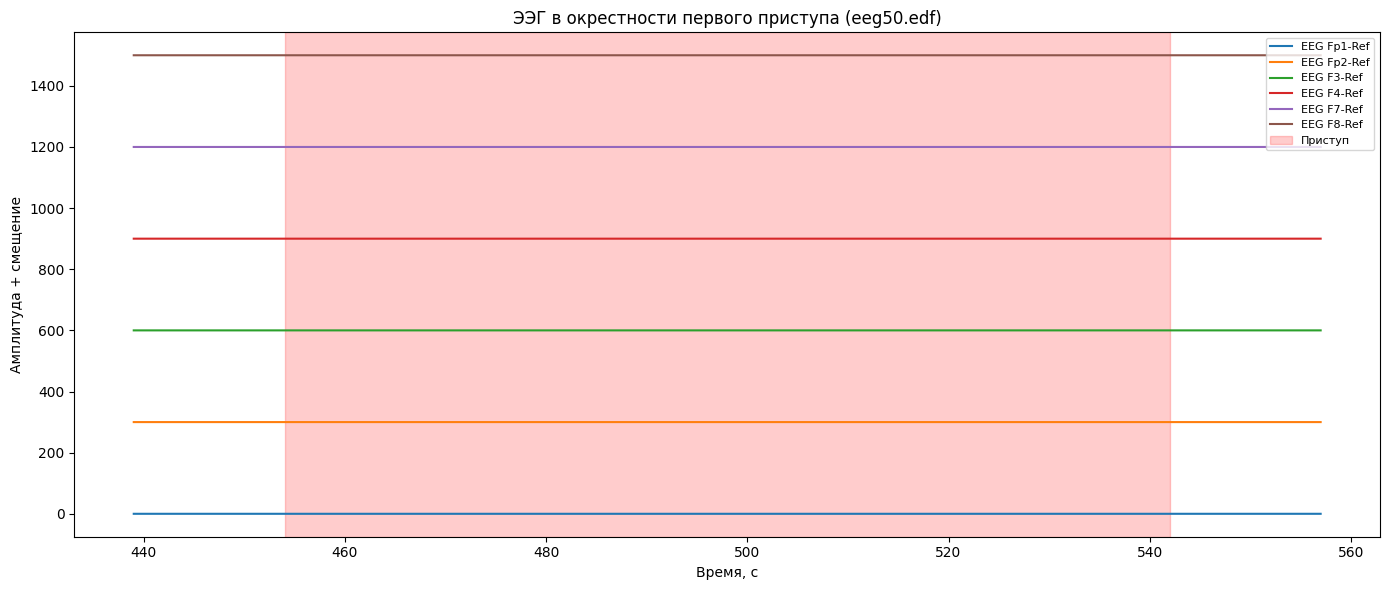

In [17]:
sfreq = raw_eeg.info["sfreq"]

plot_start_sec = max(0, seizure_start_sec - 15)
plot_end_sec = min(raw_eeg.times[-1], seizure_end_sec + 15)

start_sample = int(plot_start_sec * sfreq)
end_sample = int(plot_end_sec * sfreq)

data_segment = raw_eeg.get_data(start=start_sample, stop=end_sample)
time_segment = np.arange(data_segment.shape[1]) / sfreq + plot_start_sec

plt.figure(figsize=(14, 6))
for i in range(min(6, data_segment.shape[0])): 
    plt.plot(time_segment, data_segment[i] + i * 300, label=raw_eeg.ch_names[i])

plt.axvspan(seizure_start_sec, seizure_end_sec, color="red", alpha=0.2, label="Приступ")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда + смещение")
plt.title(f"ЭЭГ в окрестности первого приступа (eeg{FILE_ID}.edf)")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("figures_lab3/eeg_time_segment.png", dpi=200, bbox_inches="tight")
plt.show()

In [18]:
full_data = raw_eeg.get_data()
avg_signal = full_data.mean(axis=0)

print("Длина усреднённого сигнала:", len(avg_signal))
print("Первые значения:", avg_signal[:10])


Длина усреднённого сигнала: 2521600
Первые значения: [ 1.62558720e-04  3.43469861e-04  4.24695434e-04 -8.51095651e-05
 -5.26922505e-04 -1.00613730e-04  4.90281399e-04  4.91109988e-04
 -4.92731132e-05 -4.63774502e-04]


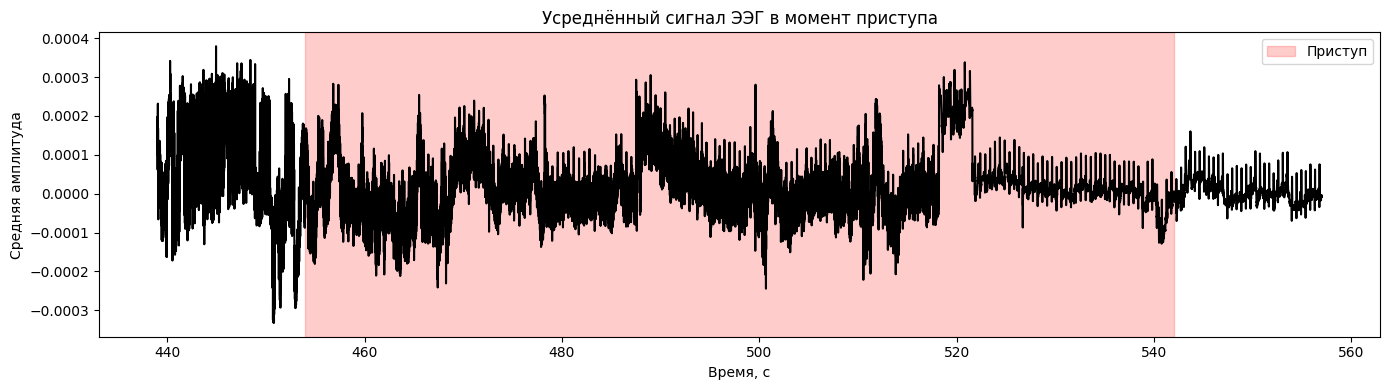

In [19]:
avg_segment = avg_signal[start_sample:end_sample]

plt.figure(figsize=(14, 4))
plt.plot(time_segment, avg_segment, color="black")
plt.axvspan(seizure_start_sec, seizure_end_sec, color="red", alpha=0.2, label="Приступ")
plt.xlabel("Время, с")
plt.ylabel("Средняя амплитуда")
plt.title("Усреднённый сигнал ЭЭГ в момент приступа")
plt.legend()
plt.tight_layout()
plt.savefig("figures_lab3/average_signal_segment.png", dpi=200, bbox_inches="tight")
plt.show()

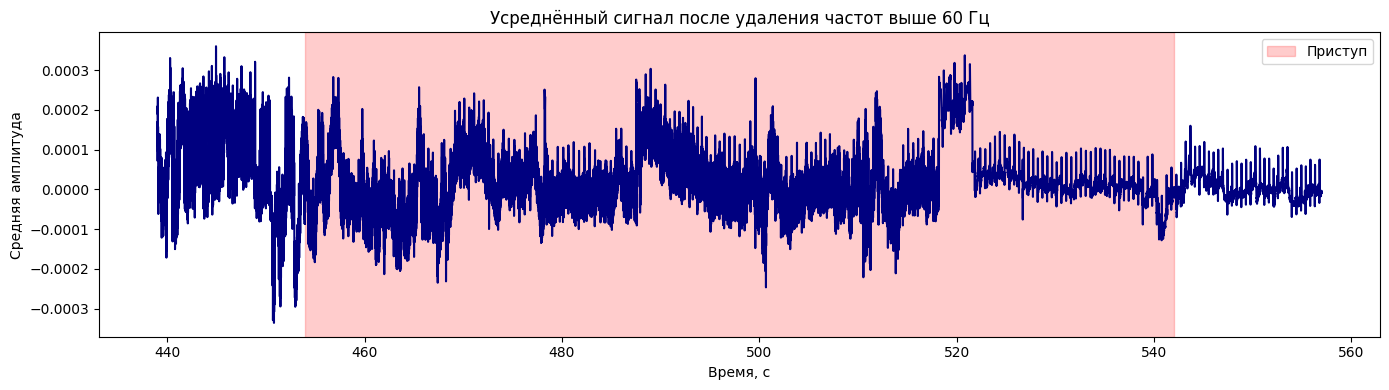

In [20]:
raw_filt = raw_eeg.copy().filter(l_freq=None, h_freq=60.0, verbose=False)
avg_signal_filt = raw_filt.get_data().mean(axis=0)
avg_segment_filt = avg_signal_filt[start_sample:end_sample]

plt.figure(figsize=(14, 4))
plt.plot(time_segment, avg_segment_filt, color="navy")
plt.axvspan(seizure_start_sec, seizure_end_sec, color="red", alpha=0.2, label="Приступ")
plt.xlabel("Время, с")
plt.ylabel("Средняя амплитуда")
plt.title("Усреднённый сигнал после удаления частот выше 60 Гц")
plt.legend()
plt.tight_layout()
plt.savefig("figures_lab3/average_signal_filtered.png", dpi=200, bbox_inches="tight")
plt.show()


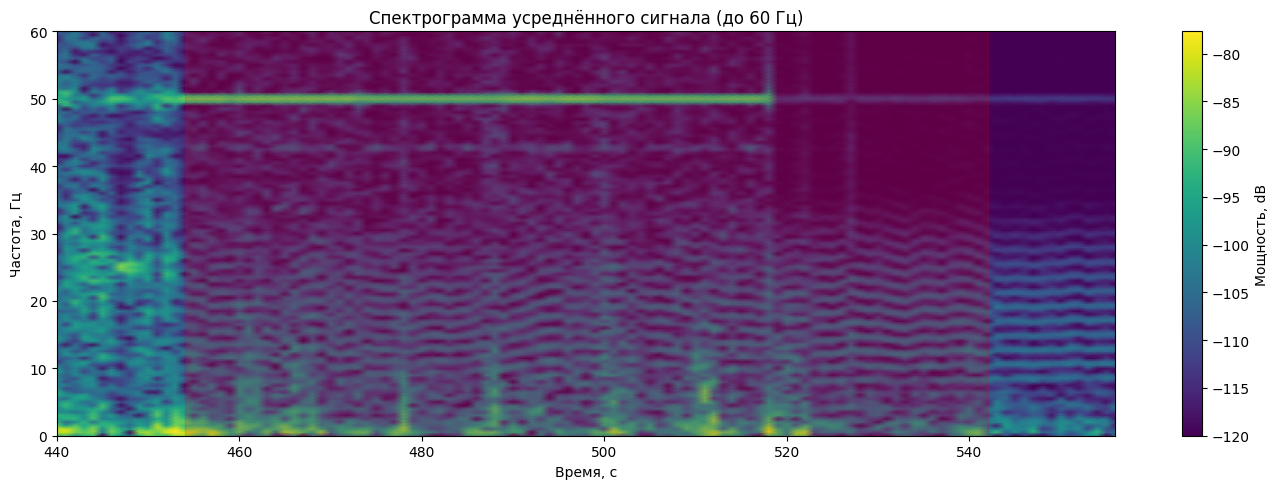

In [21]:
f, t, Sxx = signal.spectrogram(
    avg_segment_filt,
    fs=sfreq,
    window="hann",
    nperseg=min(512, len(avg_segment_filt)),
    noverlap=min(256, max(0, len(avg_segment_filt)//4))
)

plt.figure(figsize=(14, 5))
plt.pcolormesh(t + plot_start_sec, f, 10 * np.log10(Sxx + 1e-12), shading="gouraud", cmap="viridis")
plt.colorbar(label="Мощность, dB")
plt.ylim(0, 60)
plt.xlabel("Время, с")
plt.ylabel("Частота, Гц")
plt.title("Спектрограмма усреднённого сигнала (до 60 Гц)")
plt.axvspan(seizure_start_sec, seizure_end_sec, color="red", alpha=0.15)
plt.tight_layout()
plt.savefig("figures_lab3/spectrogram.png", dpi=200, bbox_inches="tight")
plt.show()

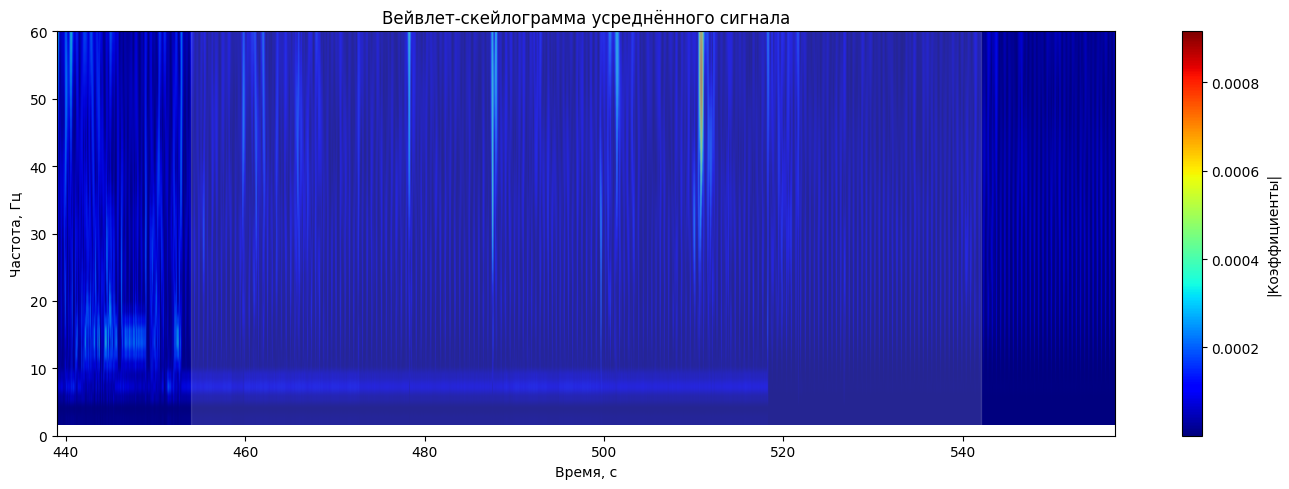

In [22]:
scales = np.arange(1, 128)
coeffs, freqs = pywt.cwt(avg_segment_filt, scales, "morl", sampling_period=1/sfreq)

plt.figure(figsize=(14, 5))
plt.imshow(
    np.abs(coeffs),
    extent=[plot_start_sec, plot_end_sec, freqs.min(), freqs.max()],
    cmap="jet",
    aspect="auto",
    origin="lower"
)
plt.colorbar(label="|Коэффициенты|")
plt.ylim(0, 60)
plt.xlabel("Время, с")
plt.ylabel("Частота, Гц")
plt.title("Вейвлет-скейлограмма усреднённого сигнала")
plt.axvspan(seizure_start_sec, seizure_end_sec, color="white", alpha=0.15)
plt.tight_layout()
plt.savefig("figures_lab3/wavelet_scalogram.png", dpi=200, bbox_inches="tight")
plt.show()


In [23]:
with open("lab3_results.txt", "w", encoding="utf-8") as f:
    f.write(f"Файл EDF: eeg{FILE_ID}.edf\n")
    f.write(f"Файл аннотаций: annotations_2017_A_fixed.csv\n")
    f.write(f"Количество каналов: {len(raw_eeg.ch_names)}\n")
    f.write(f"Частота дискретизации: {sfreq}\n")
    f.write(f"Первый интервал приступа: {seizure_start_sec} - {seizure_end_sec} сек\n")
    f.write(f"Окно визуализации: {plot_start_sec:.2f} - {plot_end_sec:.2f} сек\n")

print("Файл lab3_results.txt сохранён.")


Файл lab3_results.txt сохранён.
